<a href="https://colab.research.google.com/github/hwee-ming/smu-wrds.python/blob/main/26_0925_qf600.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
pip install wrds

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.3/4.3 MB 68.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 104.1 MB/s eta 0:00:00


In [3]:
import wrds
db = wrds.Connection()

Enter your WRDS username [root]:hmlim
Enter your password:··········
WRDS recommends setting up a .pgpass file.
Create .pgpass file now [y/n]?: n
You can create this file yourself at any time with the create_pgpass_file() function.
Loading library list...
Done


In [4]:
dsf = db.get_table(library="crsp", table="dsf_v2", obs=10)
dsf.head()

,permno,hdrcusip,permco,siccd,nasdissuno,yyyymmdd,sharetype,securitytype,securitysubtype,usincflg,...,dlyopen,dlynumtrd,dlymmcnt,dlyprcvol,dlycumfacpr,dlycumfacshr,cusip,ticker,exchangetier,shrout
0,10000,68391610,7952,3990,10396,19860107,NS,EQTY,COM,Y,...,<NA>,<NA>,9,2562.5,1.0,1.0,68391610,OMFGA,SC1,3680
1,10000,68391610,7952,3990,10396,19860108,NS,EQTY,COM,Y,...,<NA>,<NA>,9,32000.0,1.0,1.0,68391610,OMFGA,SC1,3680
2,10000,68391610,7952,3990,10396,19860109,NS,EQTY,COM,Y,...,<NA>,<NA>,9,3500.0,1.0,1.0,68391610,OMFGA,SC1,3680
3,10000,68391610,7952,3990,10396,19860110,NS,EQTY,COM,Y,...,<NA>,<NA>,10,21250.0,1.0,1.0,68391610,OMFGA,SC1,3680
4,10000,68391610,7952,3990,10396,19860113,NS,EQTY,COM,Y,...,<NA>,<NA>,10,14306.3,1.0,1.0,68391610,OMFGA,SC1,3680


In [5]:
# Query Apple daily observations
import pandas as pd
sql = """
SELECT
    ticker,
    yyyymmdd,
    dlyprc,
    dlyret
FROM crsp_a_stock.wrds_dsfv2_query
WHERE ticker = 'AAPL'
  AND yyyymmdd BETWEEN '20230101' AND '20231231'
ORDER BY yyyymmdd
"""

df = db.raw_sql(sql)

# Convert date
df['date'] = pd.to_datetime(
    df['yyyymmdd'].astype(str),
    format='%Y%m%d'
)

# CRSP price field may be stored as negative
df['price'] = df['dlyprc'].abs()

# Calculate simple return ourselves
df['calc_ret'] = (
    df['price'] /
    df['price'].shift(1)
) - 1

# Calculate gross return (1+R)
df['gross_ret'] = 1 + df['calc_ret']

# Select output columns
result = df[
    [
        'date',
        'price',
        'calc_ret',
        'gross_ret',
        'dlyret'
    ]
]

print(result.head(10))

        date   price  calc_ret  gross_ret    dlyret
0 2023-01-03  125.07      <NA>       <NA> -0.037405
1 2023-01-04  126.36  0.010314   1.010314  0.010314
2 2023-01-05  125.02 -0.010605   0.989395 -0.010605
3 2023-01-06  129.62  0.036794   1.036794  0.036794
4 2023-01-09  130.15  0.004089   1.004089  0.004089
5 2023-01-10  130.73  0.004456   1.004456  0.004456
6 2023-01-11  133.49  0.021112   1.021112  0.021112
7 2023-01-12  133.41 -0.000599   0.999401 -0.000599
8 2023-01-13  134.76  0.010119   1.010119  0.010119
9 2023-01-17  135.94  0.008756   1.008756  0.008756


In [6]:
import wrds
import pandas as pd
import numpy as np

# Apple daily prices for 2023
sql = """
SELECT
    ticker,
    permno,
    yyyymmdd,
    dlyprc,
    dlyret
FROM crsp_a_stock.wrds_dsfv2_query
WHERE ticker = 'AAPL'
    AND yyyymmdd BETWEEN '20230101' AND '20231231'
ORDER BY yyyymmdd
"""

df = db.raw_sql(sql)

# Convert date
df['yyyymmdd'] = pd.to_datetime(
    df['yyyymmdd'].astype(str),
    format='%Y%m%d'
)

# CRSP sometimes stores negative prices
df['price'] = df['dlyprc'].abs()

# Log return
df['log_return'] = np.log(
    df['price'] / df['price'].shift(1)
)

# Remove first NA row
df = df.dropna(subset=['log_return'])

print(df)

# Summary statistics
print("\nSummary Statistics")
print(df['log_return'].describe())

    ticker  permno   yyyymmdd  dlyprc    dlyret   price  log_return
1     AAPL   14593 2023-01-04  126.36  0.010314  126.36    0.010261
2     AAPL   14593 2023-01-05  125.02 -0.010605  125.02   -0.010661
3     AAPL   14593 2023-01-06  129.62  0.036794  129.62    0.036133
4     AAPL   14593 2023-01-09  130.15  0.004089  130.15    0.004081
5     AAPL   14593 2023-01-10  130.73  0.004456  130.73    0.004446
..     ...     ...        ...     ...       ...     ...         ...
245   AAPL   14593 2023-12-22   193.6 -0.005548   193.6   -0.005563
246   AAPL   14593 2023-12-26  193.05 -0.002841  193.05   -0.002845
247   AAPL   14593 2023-12-27  193.15  0.000518  193.15    0.000518
248   AAPL   14593 2023-12-28  193.58  0.002226  193.58    0.002224
249   AAPL   14593 2023-12-29  192.53 -0.005424  192.53   -0.005439

[249 rows x 7 columns]

Summary Statistics
count       249.0
mean     0.001732
std      0.012545
min     -0.049211
25%     -0.006181
50%      0.001795
75%      0.008807
max      0.045

In [7]:
# Query Apple daily prices
sql = """
SELECT
    ticker,
    yyyymmdd,
    dlyprc
FROM crsp_a_stock.wrds_dsfv2_query
WHERE ticker = 'AAPL'
  AND yyyymmdd BETWEEN '20230101' AND '20231231'
ORDER BY yyyymmdd
"""

df = db.raw_sql(sql)

# Convert date
df['date'] = pd.to_datetime(
    df['yyyymmdd'].astype(str),
    format='%Y%m%d'
)

# CRSP prices can occasionally be negative
df['price'] = df['dlyprc'].abs()

# Calculate (1+R)
df['1+R'] = df['price'] / df['price'].shift(1)

# Calculate simple return R
df['R'] = df['1+R'] - 1

print(df[['date','price','1+R','R']])

          date   price       1+R         R
0   2023-01-03  125.07      <NA>      <NA>
1   2023-01-04  126.36  1.010314  0.010314
2   2023-01-05  125.02  0.989395 -0.010605
3   2023-01-06  129.62  1.036794  0.036794
4   2023-01-09  130.15  1.004089  0.004089
..         ...     ...       ...       ...
245 2023-12-22   193.6  0.994452 -0.005548
246 2023-12-26  193.05  0.997159 -0.002841
247 2023-12-27  193.15  1.000518  0.000518
248 2023-12-28  193.58  1.002226  0.002226
249 2023-12-29  192.53  0.994576 -0.005424

[250 rows x 4 columns]


In [8]:
#Analysing Stock Prices Using Log Returns
import wrds
import pandas as pd

# Query Google daily stock prices using Log returns
sql = """
SELECT
    ticker,
    yyyymmdd,
    dlyopen,
    dlyhigh,
    dlylow,
    dlyprc,
    dlyvol
FROM crsp_a_stock.wrds_dsfv2_query
WHERE ticker = 'GOOG'
  AND yyyymmdd BETWEEN '20230101' AND '20230131'
ORDER BY yyyymmdd
"""

df = db.raw_sql(sql)

# Convert date
df['Date'] = pd.to_datetime(
    df['yyyymmdd'].astype(str),
    format='%Y%m%d'
)

# CRSP may store prices as negative values
df['Open'] = df['dlyopen'].abs()
df['High'] = df['dlyhigh'].abs()
df['Low'] = df['dlylow'].abs()
df['Close'] = df['dlyprc'].abs()

# Adjusted Close
# For a simple classroom example we'll use Close.
# If your WRDS installation contains adjustment factors,
# you can derive an adjusted price series separately.
df['Adj Close'] = df['Close']

df['Volume'] = df['dlyvol']

# Calculate single-period percentage returns
df['Return'] = df['Close'].pct_change()

# Show first 5 trading days
returns = df[
    ['Date','Open','High','Low',
     'Close','Adj Close',
     'Volume','Return']
].head(5)

print(returns)

        Date    Open   High    Low  Close  Adj Close      Volume    Return
0 2023-01-03   89.83  91.55  89.02   89.7       89.7  20710597.0      <NA>
1 2023-01-04   91.01  91.24   87.8  88.71      88.71  26980137.0 -0.011037
2 2023-01-05   88.07  88.21  86.56  86.77      86.77  23110412.0 -0.021869
3 2023-01-06   87.36  88.47  85.57  88.16      88.16  26576387.0  0.016019
4 2023-01-09  89.195  90.83  88.58   88.8       88.8  22948264.0   0.00726


In [9]:
sql = """
SELECT
    ticker,
    yyyymmdd,
    dlyprc
FROM crsp_a_stock.wrds_dsfv2_query
WHERE ticker = 'GOOGL'
  AND yyyymmdd BETWEEN '20230101' AND '20230131'
ORDER BY yyyymmdd
"""

df = db.raw_sql(sql)

# Convert date
df['Date'] = pd.to_datetime(
    df['yyyymmdd'].astype(str),
    format='%Y%m%d'
)

# CRSP prices may be negative
df['Close'] = df['dlyprc'].abs()

# Keep first 5 trading days
df5 = df.head(5)

print(df5[['Date','Close']])

# Terminal Return
terminal_return = (
    df5['Close'].iloc[-1]
    /
    df5['Close'].iloc[0]
) - 1

print(
    f"\nTerminal Return (Day 1 to Day 5) = "
    f"{terminal_return:.2%}"
)

        Date  Close
0 2023-01-03  89.12
1 2023-01-04  88.08
2 2023-01-05   86.2
3 2023-01-06  87.34
4 2023-01-09  88.02

Terminal Return (Day 1 to Day 5) = -1.23%


In [10]:
# Query Google daily prices
sql = """
SELECT
    ticker,
    yyyymmdd,
    dlyprc
FROM crsp_a_stock.wrds_dsfv2_query
WHERE ticker='GOOGL'
  AND yyyymmdd BETWEEN '20230101' AND '20230131'
ORDER BY yyyymmdd
"""

df = db.raw_sql(sql)

# Convert date
df['Date'] = pd.to_datetime(
    df['yyyymmdd'].astype(str),
    format='%Y%m%d'
)

# CRSP prices can be negative
df['Close'] = df['dlyprc'].abs()

# Keep first 5 trading days
df = df.head(5)

# Daily returns
df['Return'] = df['Close'].pct_change()

# Gross returns (1+R)
df['Gross_Return'] = 1 + df['Return']

# Cumulative return
df['Cum_Return'] = (
    df['Gross_Return']
      .cumprod()
      - 1
)

print(
    df[
        ['Date',
         'Close',
         'Return',
         'Gross_Return',
         'Cum_Return']
    ]
)

        Date  Close    Return  Gross_Return  Cum_Return
0 2023-01-03  89.12      <NA>          <NA>        <NA>
1 2023-01-04  88.08  -0.01167       0.98833    -0.01167
2 2023-01-05   86.2 -0.021344      0.978656   -0.032765
3 2023-01-06  87.34  0.013225      1.013225   -0.019973
4 2023-01-09  88.02  0.007786      1.007786   -0.012343


In [11]:
import numpy as np

sql = """
SELECT
    ticker,
    yyyymmdd,
    dlyprc
FROM crsp_a_stock.wrds_dsfv2_query
WHERE ticker='GOOGL'
  AND yyyymmdd BETWEEN '20230101' AND '20230131'
ORDER BY yyyymmdd
"""

df = db.raw_sql(sql)

# Convert date
df['Date'] = pd.to_datetime(
    df['yyyymmdd'].astype(str),
    format='%Y%m%d'
)

# CRSP prices may be stored as negative values
df['Close'] = df['dlyprc'].abs()

# Keep first 5 trading days
df = df.head(5)

# Daily returns
df['Return'] = df['Close'].pct_change()

# Method 1: Terminal return from prices
terminal_return_price = (
    df['Close'].iloc[-1]
    /
    df['Close'].iloc[0]
) - 1

# Method 2: Terminal return using cumprod()
terminal_return_cumprod = (
    (1 + df['Return'])
    .cumprod()
    .iloc[-1]
    - 1
)

print(f"Price-based Terminal Return : {terminal_return_price:.8f}")
print(f"Cumprod Terminal Return     : {terminal_return_cumprod:.8f}")


Price-based Terminal Return : -0.01234291
Cumprod Terminal Return     : -0.01234291


In [12]:
sql = """
SELECT
    ticker,
    yyyymmdd,
    dlyopen,
    dlyhigh,
    dlylow,
    dlyprc,
    dlyvol
FROM crsp_a_stock.wrds_dsfv2_query
WHERE ticker = 'AAPL'
  AND yyyymmdd BETWEEN '20220101' AND '20230101'
ORDER BY yyyymmdd
"""

df = db.raw_sql(sql)

# Convert date
df['Date'] = pd.to_datetime(
    df['yyyymmdd'].astype(str),
    format='%Y%m%d'
)

# CRSP prices are sometimes stored as negative values
df['Open'] = df['dlyopen'].abs()
df['High'] = df['dlyhigh'].abs()
df['Low'] = df['dlylow'].abs()
df['Close'] = df['dlyprc'].abs()

# Volume
df['Volume'] = df['dlyvol']

# Select final columns
df = df[
    ['Date',
     'Open',
     'High',
     'Low',
     'Close',
     'Volume']
]

print(df.head())
print(df.tail())

        Date    Open    High     Low   Close       Volume
0 2022-01-03  177.83  182.88  177.71  182.01  104656435.0
1 2022-01-04  182.63  182.94  179.12   179.7   99155535.0
2 2022-01-05  179.61  180.17  174.64  174.92   94423171.0
3 2022-01-06   172.7   175.3  171.64   172.0   96820640.0
4 2022-01-07  172.89  174.14  171.03  172.17   87650955.0
          Date    Open      High     Low   Close      Volume
246 2022-12-23  130.92   132.415  129.64  131.86  63774202.0
247 2022-12-27  131.38    131.41  128.72  130.03  68945851.0
248 2022-12-28  129.67  131.0275  125.87  126.04  85375557.0
249 2022-12-29  127.99  130.4814  127.73  129.61  75528589.0
250 2022-12-30  128.41    129.95  127.43  129.93  76988230.0


In [13]:
sql = """
select
    dlycaldt as date,
    ticker,
    dlyopen  as open,
    dlyhigh  as high,
    dlylow   as low,
    dlyclose as close,
    dlyclose / dlycumfacpr as adjusted_close,
    dlyvol   as volume
from crsp_a_stock.dsf_v2
where ticker = 'AAPL'
  and dlycaldt between '2022-01-01' and '2023-01-01'
order by dlycaldt
"""

apple = db.raw_sql(sql, date_cols=['date'])
print(apple.head())

        date ticker    open    high     low   close  adjusted_close  \
0 2022-01-03   AAPL  177.83  182.88  177.71  182.01          182.01   
1 2022-01-04   AAPL  182.63  182.94  179.12   179.7           179.7   
2 2022-01-05   AAPL  179.61  180.17  174.64  174.92          174.92   
3 2022-01-06   AAPL   172.7   175.3  171.64   172.0           172.0   
4 2022-01-07   AAPL  172.89  174.14  171.03  172.17          172.17   

        volume  
0  104656435.0  
1   99155535.0  
2   94423171.0  
3   96820640.0  
4   87650955.0  


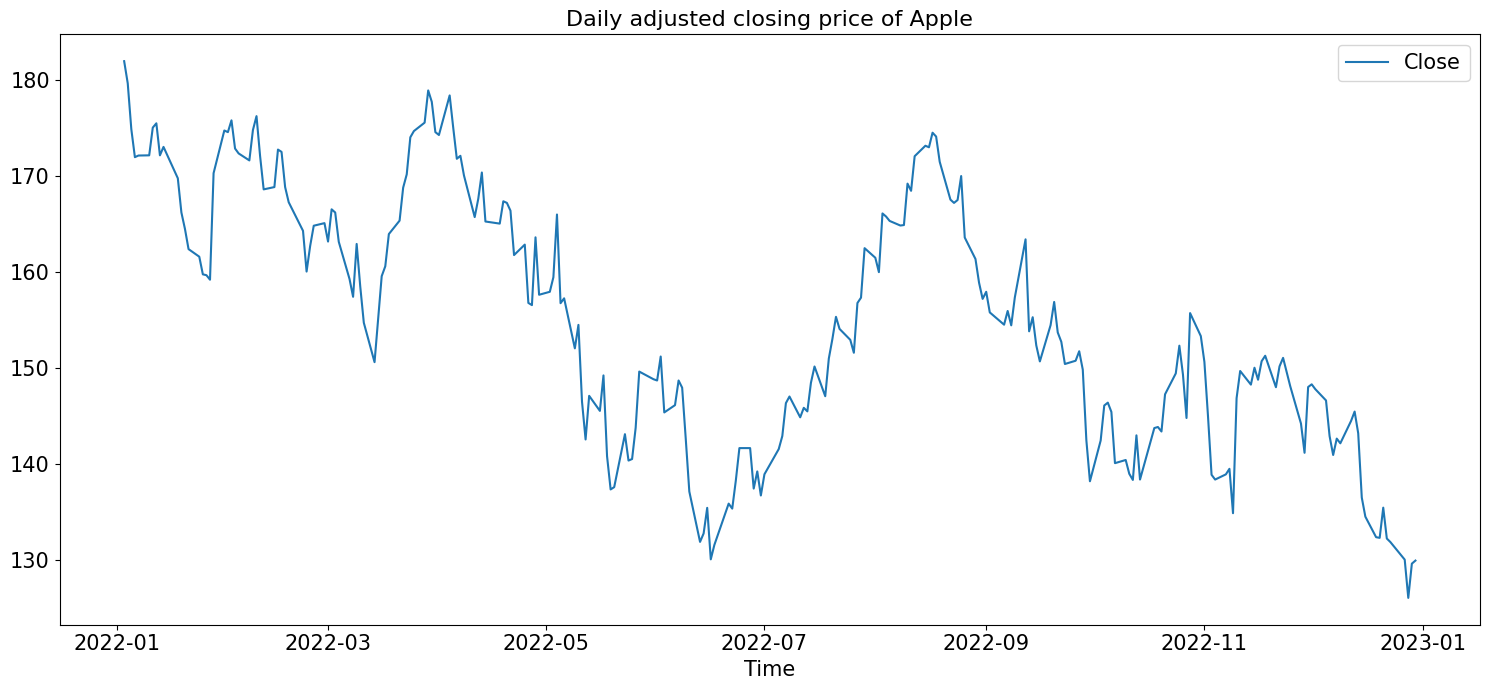

In [14]:
#plot the adj closing price
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 7))
plt.plot(apple['date'], apple['adjusted_close'], label='Close')

plt.xlabel('Time', fontsize=15)
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
plt.legend(prop={'size': 15})
plt.title('Daily adjusted closing price of Apple', fontsize=16)

plt.tight_layout()
plt.show()

In [16]:
import pandas as pd
import plotly.graph_objects as go

# make sure date is datetime
apple['date'] = pd.to_datetime(apple['date'])

fig = go.Figure()

fig.add_trace(
    go.Scatter(
        x=apple['date'],
        y=apple['adjusted_close'],
        mode='lines',
        name='Close',
        hovertemplate='Date: %{x|%Y-%m-%d}<br>Close: %{y:.2f}<extra></extra>'
    )
)

fig.update_layout(
    title='Daily adjust closing price of Apple',
    title_font_size=16,
    width=1500,
    height=700,
    xaxis_title='Date',
    yaxis_title='Close',
    xaxis=dict(
        tickfont=dict(size=15),
        title_font=dict(size=15)
    ),
    yaxis=dict(
        tickfont=dict(size=15)
    ),
    legend=dict(
        font=dict(size=15)
    )
)

fig.show(config={'scrollZoom': True})

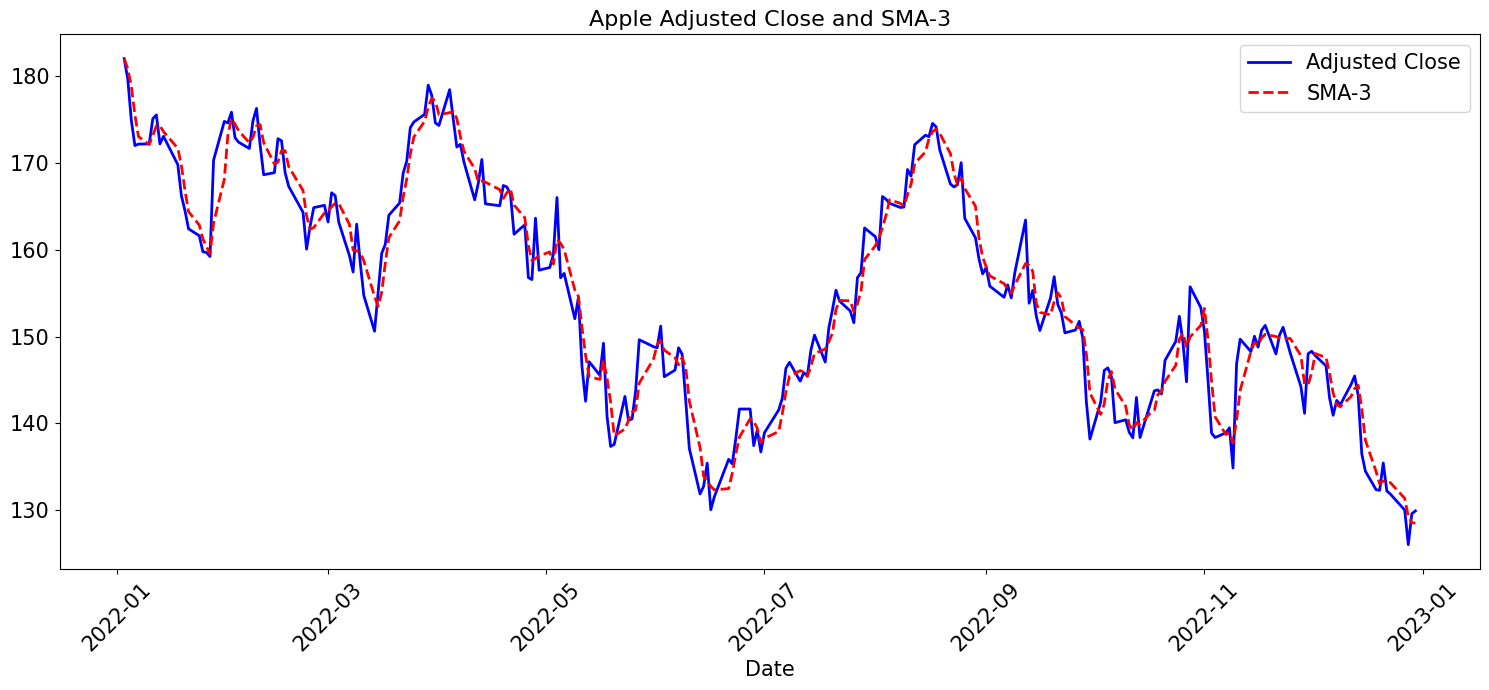

In [20]:
import pandas as pd
import matplotlib.pyplot as plt

# apple must contain: date, adjusted_close
apple['date'] = pd.to_datetime(apple['date'])
apple = apple.sort_values('date')

# SMA with window = 3 and min_periods = 1
apple['sma_3'] = apple['adjusted_close'].rolling(window=3, min_periods=1).mean()

# Plot
plt.figure(figsize=(15, 7))
plt.plot(apple['date'], apple['adjusted_close'], color='blue', linewidth=2, label='Adjusted Close')
plt.plot(apple['date'], apple['sma_3'], color='red', linewidth=2, linestyle='--', label='SMA-3')

plt.xlabel('Date', fontsize=15)
plt.xticks(rotation=45, fontsize=15)
plt.yticks(fontsize=15)
plt.title('Apple Adjusted Close and SMA-3', fontsize=16)
plt.legend(fontsize=15, loc='upper right')

plt.tight_layout()
plt.show()

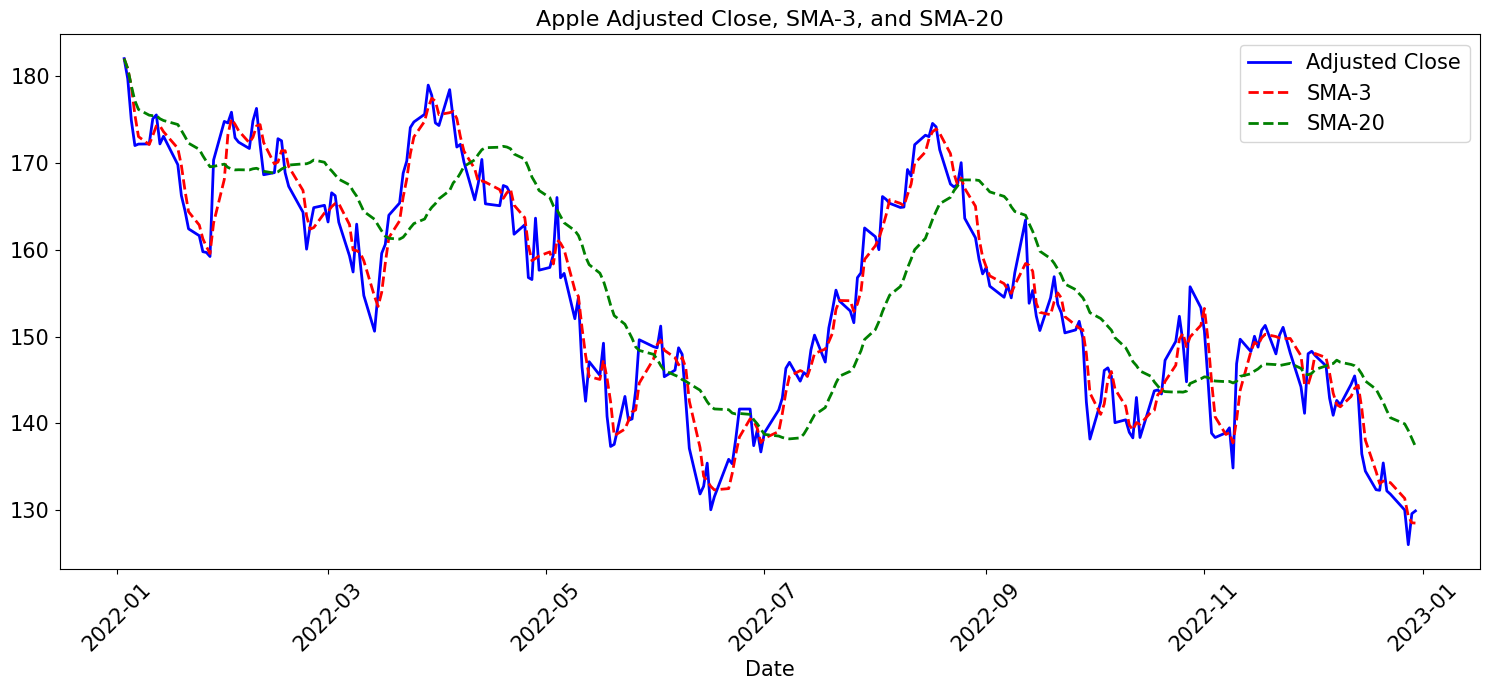

In [19]:
import pandas as pd
import matplotlib.pyplot as plt

apple['date'] = pd.to_datetime(apple['date'])
apple = apple.sort_values('date')

apple['sma_3'] = apple['adjusted_close'].rolling(window=3, min_periods=1).mean()
apple['sma_20'] = apple['adjusted_close'].rolling(window=20, min_periods=1).mean()

plt.figure(figsize=(15, 7))

plt.plot(apple['date'], apple['adjusted_close'], color='blue', linewidth=2, label='Adjusted Close')
plt.plot(apple['date'], apple['sma_3'], color='red', linewidth=2, linestyle='--', label='SMA-3')
plt.plot(apple['date'], apple['sma_20'], color='green', linewidth=2, linestyle='--', label='SMA-20')

plt.xlabel('Date', fontsize=15)
plt.xticks(rotation=45, fontsize=15)
plt.yticks(fontsize=15)
plt.title('Apple Adjusted Close, SMA-3, and SMA-20', fontsize=16)

plt.legend(fontsize=15, loc='upper right')
plt.tight_layout()
plt.show()

In [1]:
import pandas as pd
import plotly.graph_objects as go

# Ensure date is datetime and sorted
apple['date'] = pd.to_datetime(apple['date'])
apple = apple.sort_values('date')

# Moving averages
apple['sma_3'] = apple['adjusted_close'].rolling(window=3, min_periods=1).mean()
apple['sma_20'] = apple['adjusted_close'].rolling(window=20, min_periods=1).mean()

fig = go.Figure()

# Adjusted Close - blue solid
fig.add_trace(
    go.Scatter(
        x=apple['date'],
        y=apple['adjusted_close'],
        mode='lines',
        name='Adjusted Close',
        line=dict(color='blue', width=2),
        hovertemplate='Date: %{x|%Y-%m-%d}<br>Adjusted Close: %{y:.2f}<extra></extra>'
    )
)

# SMA-3 - red dashed
fig.add_trace(
    go.Scatter(
        x=apple['date'],
        y=apple['sma_3'],
        mode='lines',
        name='SMA-3',
        line=dict(color='red', width=2, dash='dash'),
        hovertemplate='Date: %{x|%Y-%m-%d}<br>SMA-3: %{y:.2f}<extra></extra>'
    )
)

# SMA-20 - green dashed
fig.add_trace(
    go.Scatter(
        x=apple['date'],
        y=apple['sma_20'],
        mode='lines',
        name='SMA-20',
        line=dict(color='green', width=2, dash='dash'),
        hovertemplate='Date: %{x|%Y-%m-%d}<br>SMA-20: %{y:.2f}<extra></extra>'
    )
)

fig.update_layout(
    title='Apple Adjusted Close, SMA-3',
    title_font_size=16,
    width=1500,
    height=700,
    xaxis_title='Date',
    yaxis_title='Price',
    xaxis=dict(
        tickfont=dict(size=15),
        title_font=dict(size=15),
        tickangle=45
    ),
    yaxis=dict(tickfont=dict(size=15)),
    legend=dict(font=dict(size=15))
)

fig.show(config={'scrollZoom': True})

NameError: name 'apple' is not defined

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Ensure date is datetime and sorted
apple['date'] = pd.to_datetime(apple['date'])
apple = apple.sort_values('date').reset_index(drop=True)

# Moving averages
apple['sma_3'] = apple['adjusted_close'].rolling(window=3, min_periods=1).mean()
apple['sma_20'] = apple['adjusted_close'].rolling(window=20, min_periods=1).mean()

# Exponential moving average with alpha = 0.1
apple['ema_alpha_0_1'] = apple['adjusted_close'].ewm(alpha=0.1, adjust=False).mean()

# Display the columns
apple_display = apple[['date', 'adjusted_close', 'sma_3', 'sma_20', 'ema_alpha_0_1']]
print(apple_display.head())
apple_display.head(10)
print(apple_display.head(10).to_string(index=False))


In [ ]:
plt.figure(figsize=(15, 7))

plt.plot(apple['date'], apple['adjusted_close'], color='blue', linewidth=2, label='Adjusted Close')
plt.plot(apple['date'], apple['sma_3'], color='red', linewidth=2, linestyle='--', label='SMA-3')
plt.plot(apple['date'], apple['sma_20'], color='green', linewidth=2, linestyle='--', label='SMA-20')
plt.plot(apple['date'], apple['ema_alpha_0_1'], color='purple', linewidth=2, linestyle='-', label='EMA (alpha=0.1)')

plt.xlabel('Time', fontsize=15)
plt.xticks(rotation=45, fontsize=15)
plt.yticks(fontsize=15)
plt.title('Daily Apple adjusted closing price with SMA-3, SMA-20, and EMA (alpha=0.1)', fontsize=16)
plt.legend(fontsize=15, loc='upper right')

plt.tight_layout()
plt.show()

In [ ]:
# Ensure date is datetime and sorted
apple['date'] = pd.to_datetime(apple['date'])
apple = apple.sort_values('date').reset_index(drop=True)

# Moving averages
apple['sma_3'] = apple['adjusted_close'].rolling(window=3, min_periods=1).mean()
apple['sma_20'] = apple['adjusted_close'].rolling(window=20, min_periods=1).mean()

# Exponential moving average with alpha = 0.05 and alpha = 0.1
apple['ema_alpha_0_05'] = apple['adjusted_close'].ewm(alpha=0.05, adjust=False).mean()
apple['ema_alpha_0_1'] = apple['adjusted_close'].ewm(alpha=0.1, adjust=False).mean()

# Review table
apple_display = apple[['date', 'adjusted_close', 'sma_3', 'sma_20', 'ema_alpha_0_05', 'ema_alpha_0_1']]
print(apple_display.head(10).to_string(index=False))

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Ensure date is datetime and sorted
apple['date'] = pd.to_datetime(apple['date'])
apple = apple.sort_values('date').reset_index(drop=True)

# Moving averages
apple['sma_3'] = apple['adjusted_close'].rolling(window=3, min_periods=1).mean()
apple['sma_20'] = apple['adjusted_close'].rolling(window=20, min_periods=1).mean()

# Exponential moving averages
apple['ema_alpha_0_1'] = apple['adjusted_close'].ewm(alpha=0.1, adjust=False).mean()
apple['ema_alpha_0_05'] = apple['adjusted_close'].ewm(alpha=0.05, adjust=False).mean()

# Plot
plt.figure(figsize=(15, 7))

plt.plot(apple['date'], apple['adjusted_close'], color='blue', linewidth=2, label='Adjusted Close')
plt.plot(apple['date'], apple['sma_3'], color='red', linewidth=2, linestyle='--', label='SMA-3')
plt.plot(apple['date'], apple['sma_20'], color='green', linewidth=2, linestyle='--', label='SMA-20')
plt.plot(apple['date'], apple['ema_alpha_0_1'], color='purple', linewidth=2, label='EMA (alpha=0.1)')
plt.plot(apple['date'], apple['ema_alpha_0_05'], color='orange', linewidth=2, label='EMA (alpha=0.05)')

plt.xlabel('Date', fontsize=15)
plt.xticks(rotation=45, fontsize=15)
plt.yticks(fontsize=15)
plt.title('Daily Apple Adjusted Closing price with SMA-3, SMA-20, and EMA (alpha=0.1 and alpha =0.05)', fontsize=16)
plt.legend(fontsize=15, loc='upper right')

plt.tight_layout()
plt.show()

In [ ]:
apple_display.info()

In [ ]:
apple['sma_3_future'] = apple['sma_3'].shift(1)
apple['sma_20_future'] = apple['sma_20'].shift(1)
#identify buy signal
apple['signal']=np.where(apple['sma_3_future'] > apple['sma_20_future'],1,0)

#identify sell signal
apple['signal'] = np.where(apple['sma_3_future'] < apple['sma_20_future'], -1, apple['signal'])
apple.dropna(inplace=True)

apple['signal'].value_counts()


In [ ]:
apple['log_return_buy_n_hold'] = np.log(apple['adjusted_close']).diff()

apple['log_return_trend_follow'] = apple['signal'] * apple['log_return_buy_n_hold']

apple['action'] = apple.signal.diff()
apple['action'].value_counts()


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

plt.rcParams['figure.figsize'] = (12, 6)
plt.grid(True, alpha=0.3)

plt.plot(apple['date'], apple['adjusted_close'], label='Adj Close', color='blue')
plt.plot(apple['date'], apple['sma_3'], label='SMA-3', color='red')
plt.plot(apple['date'], apple['sma_20'], label='SMA-20', color='green')

# Buy signals: action == 2
plt.plot(
    apple.loc[apple.action == 2, 'date'],
    apple.loc[apple.action == 2, 'sma_3'],
    '^',
    color='g',
    markersize=12,
    label='Buy'
)

# Sell signals: action == -2
plt.plot(
    apple.loc[apple.action == -2, 'date'],
    apple.loc[apple.action == -2, 'sma_20'],
    'v',
    color='r',
    markersize=12,
    label='Sell'
)

# Date formatting
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
plt.xticks(rotation=45)

plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
plt.plot(np.exp(apple['log_return_buy_n_hold']).cumprod(), label='Buy-n-hold')
plt.plot(np.exp(apple['log_return_trend_follow']).cumprod(), label='Trend following')
plt.legend(loc=2)
plt.title("Cummulative return of different trading strategies")
plt.grid(True, alpha=0.3)
